Epoch 0 Loss 0.4379144012928009
Epoch 300 Loss 0.038094308227300644
Epoch 600 Loss 0.027681740000844002
Epoch 900 Loss 0.022071518003940582
Epoch 1200 Loss 0.018706006929278374
Epoch 1500 Loss 0.01681373454630375
Epoch 1800 Loss 0.015372823923826218
Epoch 2100 Loss 0.014773874543607235
Epoch 2400 Loss 0.013886884786188602
Epoch 2700 Loss 0.013373387977480888

===== 欠損点予測 =====

(8,0) 予測=0.4296 真値=0.3294 誤差=0.1002
(14,0) 予測=0.6122 真値=0.3569 誤差=0.2553
(32,0) 予測=0.6062 真値=0.5137 誤差=0.0925
(33,0) 予測=0.6242 真値=0.6078 誤差=0.0164
(43,0) 予測=0.4830 真値=0.4157 誤差=0.0673
(6,1) 予測=0.3758 真値=0.4235 誤差=0.0477
(32,1) 予測=0.5486 真値=0.6549 誤差=0.1063
(45,1) 予測=0.5954 真値=0.5804 誤差=0.0150
(4,2) 予測=0.4700 真値=0.6706 誤差=0.2005
(21,2) 予測=0.4624 真値=0.5647 誤差=0.1023
(38,2) 予測=0.6905 真値=0.6824 誤差=0.0082
(51,2) 予測=0.6629 真値=0.7255 誤差=0.0626
(56,2) 予測=0.4540 真値=0.6353 誤差=0.1813
(4,3) 予測=0.6141 真値=0.7490 誤差=0.1349
(19,3) 予測=0.4535 真値=0.3725 誤差=0.0809
(37,3) 予測=0.6657 真値=0.6588 誤差=0.0069
(59,3) 予測=0.5426 真値=0.5765 誤差=0

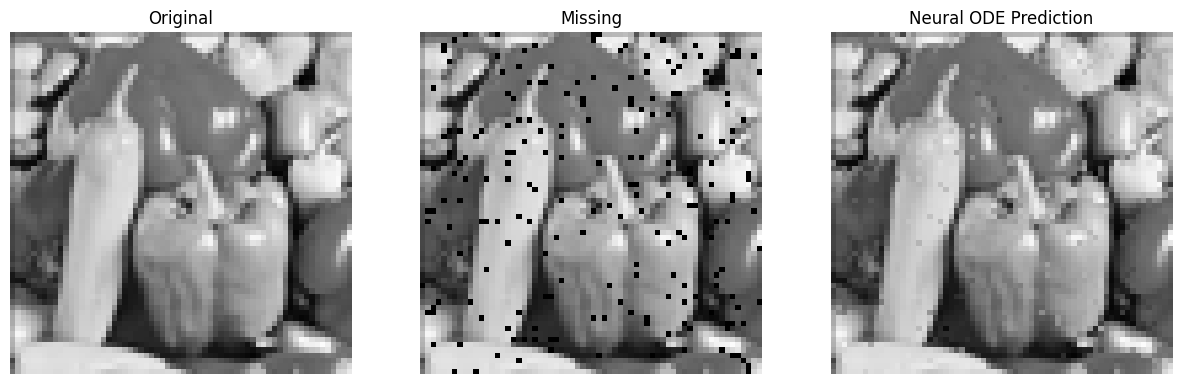

In [1]:
# ============================================
# Neural ODE 画像欠損補間
# 「既知画素は保持し、欠損画素だけ補間」
# ============================================

import numpy as np
import matplotlib.pyplot as plt

from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim

from torchdiffeq import odeint

# ============================================
# 画像読み込み
# ============================================

# 白黒画像として読み込み
img = Image.open("Images/Peppers.png").convert("L")

# 解像度
img = img.resize((64,64))

# numpy化
img_array = np.array(img).astype(np.float32)

# 画素値（色の数値：0~255の値）を0〜1正規化
img_array = img_array / 255.0

# ============================================
# 座標作成
# ============================================

height, width = img_array.shape

# 座標正規化（重要）
x = np.linspace(-1,1,width)
y = np.linspace(-1,1,height)

X, Y = np.meshgrid(x, y)

# ============================================
# 欠損作成
# ============================================

mask = np.ones(img_array.shape, dtype=bool)


# 欠損させるピクセル(座標ランダム版)

np.random.seed(42)

num_missing = int(height * width * 0.05)

indices = np.random.choice(
    height * width,
    num_missing,
    replace=False
)

missing_points = [
    (idx // width, idx % width)
    for idx in indices
]
"""
#ブロック欠損版
missing_points = []

for i in range(100,156):
    for j in range(100,156):
        missing_points.append((i,j))
# 欠損させるピクセル(座標指定版)

missing_points = [

    (20,20),
    (20,21),
    (20,22),

    (21,20),
    (21,21),
    (21,22),

    (22,20),
    (22,21),
    (22,22),

    (40,40),
    (41,41),
    (42,42)

]
"""
# 欠損化
for i,j in missing_points:

    mask[i,j] = False #欠損にしたい座標(i,j)だけをFalseにする

# 欠損画像
img_missing = img_array.copy() #元データを書き換えないためにコピーを作る

img_missing[~mask] = np.nan #欠損指定した座標だけNaNに置き換える

# ============================================
# 学習データ作成
# ============================================

coords = np.stack(
    [X.flatten(), Y.flatten()],
    axis=1
)

targets = img_array.flatten()

mask_flat = mask.flatten()

# 観測点のみ学習
coords_train = coords[mask_flat]

targets_train = targets[mask_flat]

# Tensor化
coords_tensor = torch.tensor(
    coords_train,
    dtype=torch.float32
)

targets_tensor = torch.tensor(
    targets_train,
    dtype=torch.float32
).view(-1,1)

# ============================================
# ODE Function
# ============================================

class ODEFunc(nn.Module):

    def __init__(self):

        super().__init__()

        self.net = nn.Sequential(

            nn.Linear(2,128),
            nn.Tanh(),

            nn.Linear(128,128),
            nn.Tanh(),

            nn.Linear(128,128),
            nn.Tanh(),

            nn.Linear(128,2)

        )

    def forward(self, t, h):

        return self.net(h)

# ============================================
# Neural ODE
# ============================================

class NeuralODEModel(nn.Module):

    def __init__(self):

        super().__init__()

        self.odefunc = ODEFunc()

        self.output_layer = nn.Linear(2,1)

    def forward(self, x_input):

        h0 = x_input

        t = torch.tensor([0,1]).float()

        out = odeint(
            self.odefunc,
            h0,
            t,
            method='rk4'
        )

        h_final = out[-1]

        z_pred = self.output_layer(h_final)

        return z_pred

# ============================================
# モデル
# ============================================

model = NeuralODEModel()

criterion = nn.MSELoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

# ============================================
# 学習
# ============================================

epochs = 3000

for epoch in range(epochs):

    optimizer.zero_grad()

    pred = model(coords_tensor)

    loss = criterion(
        pred,
        targets_tensor
    )

    loss.backward()

    optimizer.step()

    if epoch % 300 == 0:

        print(
            f"Epoch {epoch} "
            f"Loss {loss.item()}"
        )

# ============================================
# 全画素予測
# ============================================

all_coords_tensor = torch.tensor(
    coords,
    dtype=torch.float32
)

with torch.no_grad():

    img_pred = model(
        all_coords_tensor
    ).numpy()

img_pred = img_pred.reshape(
    height,
    width
)

# ============================================
# 欠損部分だけ補間
# ============================================

# 既知画素はそのまま
final_img = img_missing.copy()

# 欠損部分だけNeural ODE予測値を代入
final_img[~mask] = img_pred[~mask]

# ============================================
# 欠損点精度表示
# ============================================

print("\n===== 欠損点予測 =====\n")

missing_y, missing_x = np.where(~mask)

for idx in range(len(missing_x)):

    x_val = missing_x[idx]
    y_val = missing_y[idx]

    pred_val = final_img[y_val, x_val]

    true_val = img_array[y_val, x_val]

    error = abs(pred_val - true_val)

    print(
        f"({x_val},{y_val}) "
        f"予測={pred_val:.4f} "
        f"真値={true_val:.4f} "
        f"誤差={error:.4f}"
    )

# ============================================
# 欠損点MSE
# ============================================

missing_mse = np.mean(

    (
        img_array[~mask]
        -
        final_img[~mask]

    )**2
)

print("\n==============================")
print("Missing MSE :", missing_mse)
print("==============================")

# ============================================
# 可視化
# ============================================

fig, ax = plt.subplots(1,3, figsize=(15,5))

# 元画像
ax[0].imshow(
    img_array,
    cmap='gray'
)

ax[0].set_title("Original")

# 欠損画像
ax[1].imshow(
    np.nan_to_num(img_missing, nan=0),
    cmap='gray'
)

ax[1].set_title("Missing")

# 補間結果
ax[2].imshow(
    final_img,
    cmap='gray'
)

ax[2].set_title("Neural ODE Prediction")

# 軸OFF
for i in range(3):

    ax[i].axis("off")

plt.show()